## 1. Librerías y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Configuración de Rutas

In [2]:
# Rutas
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    import os
    script_dir = Path(os.getcwd()).resolve()

project_dir = script_dir.parent
data_dir = project_dir / "data_processed"
output_dir = project_dir / "data_processed"

# Archivo de entrada (datos limpios sin imputar)
input_file = data_dir / "datos_sima_limpios_combined.csv"

# Archivo de salida (datos imputados)
output_file = output_dir / "datos_sima_imputados.csv"

print(f"Archivo de entrada: {input_file}")
print(f"Archivo de salida: {output_file}")
print(f"Existe archivo de entrada: {input_file.exists()}")

Archivo de entrada: C:\Users\anala\Documents\GitHub\Reto-multivariados-equipo-3\data_processed\datos_sima_limpios_combined.csv
Archivo de salida: C:\Users\anala\Documents\GitHub\Reto-multivariados-equipo-3\data_processed\datos_sima_imputados.csv
Existe archivo de entrada: True


## 3. Carga de Datos

In [3]:
# Cargar datos
df = pd.read_csv(input_file, parse_dates=['date'])

print(f"Dimensiones originales: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones originales: (1804203, 4)

Columnas: ['date', 'estacion', 'parametro', 'valor']

Primeras filas:


,date,estacion,parametro,valor
0,2023-01-01 00:00:00,SUR,CO,2.37
1,2023-01-01 01:00:00,SUR,CO,2.12
2,2023-01-01 02:00:00,SUR,CO,2.05
3,2023-01-01 03:00:00,SUR,CO,2.50
4,2023-01-01 04:00:00,SUR,CO,1.94


## 4. Análisis de Valores Faltantes

In [8]:
# Análisis de valores faltantes
print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES ANTES DE IMPUTACIÓN")
print("=" * 60)

total_rows = len(df)
missing_info = pd.DataFrame({
    'Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / total_rows * 100).round(2)
})
missing_info = missing_info[missing_info['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

print(f"\nTotal de observaciones: {total_rows:,}")
print(f"\nValores faltantes por columna:")
print(missing_info)

# Faltantes por parámetro
if 'parametro' in df.columns and 'valor' in df.columns:
    print("\n" + "="*60)
    print("VALORES FALTANTES POR CONTAMINANTE")
    print("="*60)
    missing_by_param = df.groupby('parametro')['valor'].agg([
        ('Total', 'count'),
        ('Faltantes', lambda x: x.isna().sum()),
        ('% Faltante', lambda x: (x.isna().sum() / len(x) * 100).round(2))
    ])
    print(missing_by_param.sort_values('% Faltante', ascending=False))

# Faltantes por estación
if 'estacion' in df.columns and 'valor' in df.columns:
    print("\n" + "="*60)
    print("VALORES FALTANTES POR ESTACIÓN")
    print("="*60)
    missing_by_station = df.groupby('estacion')['valor'].agg([
        ('Total', 'count'),
        ('Faltantes', lambda x: x.isna().sum()),
        ('% Faltante', lambda x: (x.isna().sum() / len(x) * 100).round(2))
    ])
    print(missing_by_station.sort_values('% Faltante', ascending=False))

ANÁLISIS DE VALORES FALTANTES ANTES DE IMPUTACIÓN

Total de observaciones: 1,804,203

Valores faltantes por columna:
Empty DataFrame
Columns: [Faltantes, Porcentaje]
Index: []

VALORES FALTANTES POR CONTAMINANTE
            Total  Faltantes  % Faltante
parametro                               
CO         372583          0         0.0
NO2        377474          0         0.0
O3         384135          0         0.0
PM10       389741          0         0.0
PM2.5      280270          0         0.0

VALORES FALTANTES POR ESTACIÓN
            Total  Faltantes  % Faltante
estacion                                
CENTRO     127035          0         0.0
NORESTE3   340766          0         0.0
NOROESTE3  321829          0         0.0
NORTE2     258239          0         0.0
SUR        501987          0         0.0
SUROESTE2  254347          0         0.0
            Total  Faltantes  % Faltante
parametro                               
CO         372583          0         0.0
NO2        377474 

## 5. Visualización de Patrones de Valores Faltantes

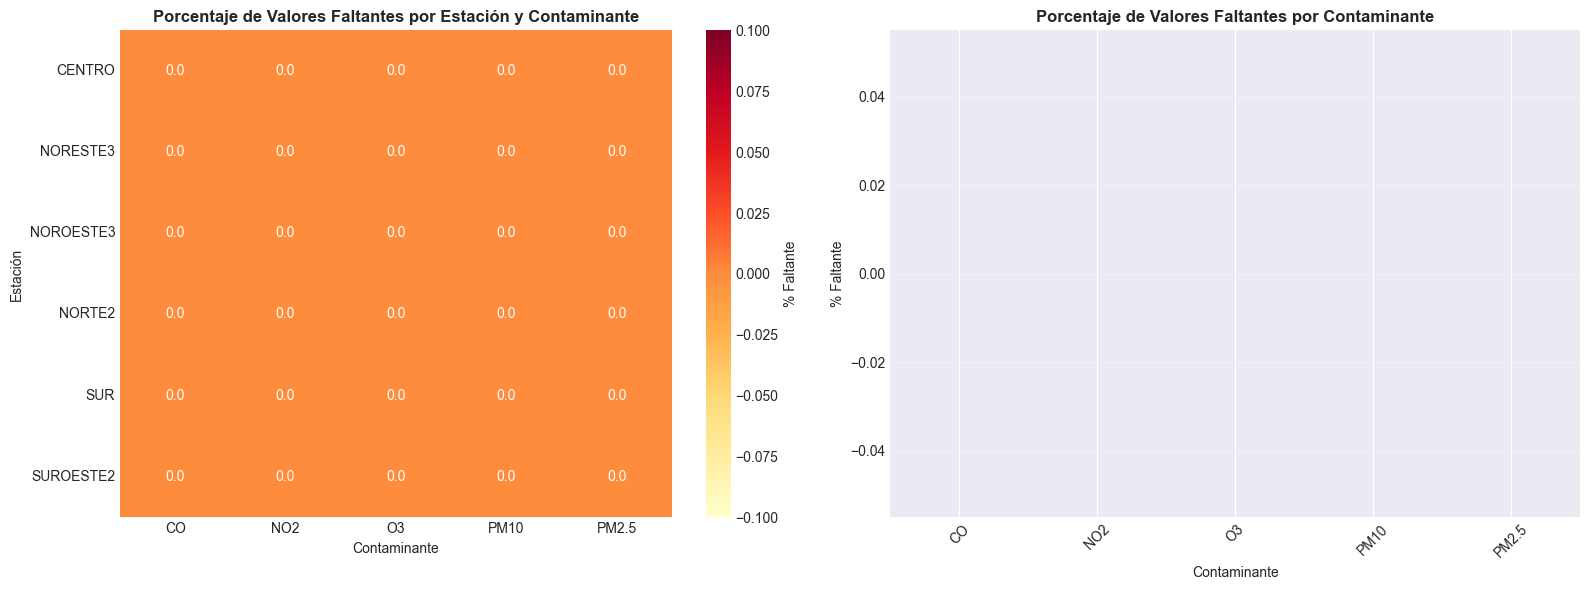

In [9]:
# Visualizar patrones de valores faltantes
if 'parametro' in df.columns and 'estacion' in df.columns and 'valor' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Mapa de calor: faltantes por estación y parámetro
    pivot_missing = df.groupby(['estacion', 'parametro'])['valor'].apply(
        lambda x: (x.isna().sum() / len(x) * 100) if len(x) > 0 else 0
    ).unstack(fill_value=0)
    
    sns.heatmap(pivot_missing, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0], cbar_kws={'label': '% Faltante'})
    axes[0].set_title('Porcentaje de Valores Faltantes por Estación y Contaminante', fontsize=12, weight='bold')
    axes[0].set_xlabel('Contaminante')
    axes[0].set_ylabel('Estación')
    
    # Gráfico de barras por parámetro
    missing_by_param = df.groupby('parametro')['valor'].apply(
        lambda x: (x.isna().sum() / len(x) * 100)
    ).sort_values(ascending=False)
    
    missing_by_param.plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Porcentaje de Valores Faltantes por Contaminante', fontsize=12, weight='bold')
    axes[1].set_xlabel('Contaminante')
    axes[1].set_ylabel('% Faltante')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Preparación para Imputación

Transformaremos los datos a formato wide (una fila por timestamp, columnas por contaminante y estación) para facilitar la imputación.

In [10]:
# Verificar si necesitamos pivotar los datos
print(f"Estructura actual: {df.columns.tolist()}")

# Crear una copia para trabajar
df_work = df.copy()

# Si los datos están en formato long (con columna 'parametro'), pivotar a wide
if 'parametro' in df_work.columns and 'valor' in df_work.columns:
    print("\nConvirtiendo datos de formato long a wide...")
    
    # Crear columna compuesta estacion_parametro
    df_work['est_param'] = df_work['estacion'].astype(str) + '_' + df_work['parametro'].astype(str)
    
    # Pivotar
    df_wide = df_work.pivot_table(
        index='date',
        columns='est_param',
        values='valor',
        aggfunc='mean'
    ).reset_index()
    
    print(f"Dimensiones después de pivotar: {df_wide.shape}")
    print(f"Columnas creadas: {len(df_wide.columns) - 1}")
    
else:
    # Los datos ya están en formato wide
    print("\nLos datos ya están en formato wide.")
    df_wide = df_work.copy()

# Ordenar por fecha
df_wide = df_wide.sort_values('date').reset_index(drop=True)

print(f"\nPrimeras filas del dataset wide:")
df_wide.head()

Estructura actual: ['date', 'estacion', 'parametro', 'valor']

Convirtiendo datos de formato long a wide...
Dimensiones después de pivotar: (21883, 31)
Columnas creadas: 30

Primeras filas del dataset wide:
Dimensiones después de pivotar: (21883, 31)
Columnas creadas: 30

Primeras filas del dataset wide:


est_param,date,CENTRO_CO,CENTRO_NO2,CENTRO_O3,CENTRO_PM10,CENTRO_PM2.5,NORESTE3_CO,NORESTE3_NO2,NORESTE3_O3,NORESTE3_PM10,...,SUROESTE2_CO,SUROESTE2_NO2,SUROESTE2_O3,SUROESTE2_PM10,SUROESTE2_PM2.5,SUR_CO,SUR_NO2,SUR_O3,SUR_PM10,SUR_PM2.5
0,2023-01-01 00:00:00,1.67,30.3,9.0,118.0,94.12,2.117333,30.666667,8.300000,129.333333,...,2.405,28.20,12.5,142.5,34.0,2.6000,58.300,6.000000,118.00,82.666667
1,2023-01-01 01:00:00,1.70,28.9,9.0,97.0,96.79,2.529667,32.266667,7.633333,188.333333,...,2.470,25.50,13.5,169.0,30.0,2.8175,48.550,7.250000,172.25,102.726667
2,2023-01-01 02:00:00,1.51,23.2,11.0,103.0,81.23,2.550333,30.933333,6.566667,355.000000,...,2.655,25.60,12.0,202.5,32.0,3.0850,52.975,7.500000,225.00,75.040000
3,2023-01-01 03:00:00,1.30,20.9,11.0,83.0,49.83,2.421000,30.533333,6.133333,269.333333,...,2.090,25.25,11.0,209.0,79.5,3.4175,44.300,6.250000,214.50,68.936667
4,2023-01-01 04:00:00,1.28,20.7,9.0,65.0,40.19,2.214000,30.666667,5.900000,235.000000,...,1.585,21.55,12.5,112.5,47.0,3.4050,48.650,7.333333,233.00,74.853333


In [11]:
# Separar fecha de valores numéricos
date_col = df_wide['date'].copy()
numeric_cols = df_wide.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df_wide[numeric_cols].copy()

print(f"Columnas numéricas para imputar: {len(numeric_cols)}")
print(f"Valores faltantes totales: {df_numeric.isnull().sum().sum():,}")
print(f"Porcentaje de faltantes: {(df_numeric.isnull().sum().sum() / df_numeric.size * 100):.2f}%")

Columnas numéricas para imputar: 30
Valores faltantes totales: 12,411
Porcentaje de faltantes: 1.89%


## 7. Método 1: Interpolación Lineal Temporal

Ideal para gaps pequeños en series temporales. Asume transición suave entre valores conocidos.

In [12]:
# Interpolación lineal
df_interp_linear = df_numeric.copy()

# Aplicar interpolación lineal con límite de 3 períodos consecutivos
df_interp_linear = df_interp_linear.interpolate(method='linear', limit=3, limit_direction='both')

missing_after = df_interp_linear.isnull().sum().sum()
missing_before = df_numeric.isnull().sum().sum()

print(f"Interpolación Lineal:")
print(f"  Valores faltantes antes: {missing_before:,}")
print(f"  Valores faltantes después: {missing_after:,}")
print(f"  Valores imputados: {missing_before - missing_after:,}")
print(f"  % Reducción: {((missing_before - missing_after) / missing_before * 100):.2f}%")

Interpolación Lineal:
  Valores faltantes antes: 12,411
  Valores faltantes después: 7,387
  Valores imputados: 5,024
  % Reducción: 40.48%


## 8. Método 2: Interpolación por Tiempo (Time-based)

Utiliza los índices temporales reales para interpolar, más apropiado cuando hay gaps irregulares en el tiempo.

In [13]:
# Interpolación temporal
df_time = df_wide.copy()
df_time = df_time.set_index('date')

# Aplicar interpolación temporal
df_interp_time = df_time.interpolate(method='time', limit=6)

missing_after_time = df_interp_time.isnull().sum().sum()

print(f"Interpolación Temporal:")
print(f"  Valores faltantes antes: {missing_before:,}")
print(f"  Valores faltantes después: {missing_after_time:,}")
print(f"  Valores imputados: {missing_before - missing_after_time:,}")
print(f"  % Reducción: {((missing_before - missing_after_time) / missing_before * 100):.2f}%")

df_interp_time = df_interp_time.reset_index()

Interpolación Temporal:
  Valores faltantes antes: 12,411
  Valores faltantes después: 7,381
  Valores imputados: 5,030
  % Reducción: 40.53%


## 9. Método 3: Forward Fill + Backward Fill

Propaga el último valor conocido hacia adelante/atrás. Útil para datos que cambian lentamente.

In [14]:
# Forward fill + Backward fill
df_ffill = df_numeric.copy()

# Primero forward fill (límite de 2 períodos)
df_ffill = df_ffill.fillna(method='ffill', limit=2)

# Luego backward fill para los que quedan (límite de 2 períodos)
df_ffill = df_ffill.fillna(method='bfill', limit=2)

missing_after_fill = df_ffill.isnull().sum().sum()

print(f"Forward/Backward Fill:")
print(f"  Valores faltantes antes: {missing_before:,}")
print(f"  Valores faltantes después: {missing_after_fill:,}")
print(f"  Valores imputados: {missing_before - missing_after_fill:,}")
print(f"  % Reducción: {((missing_before - missing_after_fill) / missing_before * 100):.2f}%")

Forward/Backward Fill:
  Valores faltantes antes: 12,411
  Valores faltantes después: 8,062
  Valores imputados: 4,349
  % Reducción: 35.04%


## 10. Método 4: KNN Imputer

Utiliza k-vecinos más cercanos. Ideal cuando estaciones cercanas tienen patrones similares.

In [15]:
# KNN Imputer
print("Aplicando KNN Imputer (esto puede tardar unos minutos)...")

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df_numeric),
    columns=df_numeric.columns,
    index=df_numeric.index
)

missing_after_knn = df_knn.isnull().sum().sum()

print(f"\nKNN Imputer:")
print(f"  Valores faltantes antes: {missing_before:,}")
print(f"  Valores faltantes después: {missing_after_knn:,}")
print(f"  Valores imputados: {missing_before - missing_after_knn:,}")
print(f"  % Reducción: {100.0:.2f}%" if missing_after_knn == 0 else f"  % Reducción: {((missing_before - missing_after_knn) / missing_before * 100):.2f}%")

Aplicando KNN Imputer (esto puede tardar unos minutos)...

KNN Imputer:
  Valores faltantes antes: 12,411
  Valores faltantes después: 0
  Valores imputados: 12,411
  % Reducción: 100.00%

KNN Imputer:
  Valores faltantes antes: 12,411
  Valores faltantes después: 0
  Valores imputados: 12,411
  % Reducción: 100.00%


## 11. Método 5: Iterative Imputer (MICE)

Modelo multivariado que considera correlaciones entre contaminantes. Similar al algoritmo MICE.

In [16]:
# Iterative Imputer
print("Aplicando Iterative Imputer (esto puede tardar varios minutos)...")

iter_imputer = IterativeImputer(max_iter=10, random_state=42, verbose=0)
df_iter = pd.DataFrame(
    iter_imputer.fit_transform(df_numeric),
    columns=df_numeric.columns,
    index=df_numeric.index
)

missing_after_iter = df_iter.isnull().sum().sum()

print(f"\nIterative Imputer:")
print(f"  Valores faltantes antes: {missing_before:,}")
print(f"  Valores faltantes después: {missing_after_iter:,}")
print(f"  Valores imputados: {missing_before - missing_after_iter:,}")
print(f"  % Reducción: {100.0:.2f}%" if missing_after_iter == 0 else f"  % Reducción: {((missing_before - missing_after_iter) / missing_before * 100):.2f}%")

Aplicando Iterative Imputer (esto puede tardar varios minutos)...

Iterative Imputer:
  Valores faltantes antes: 12,411
  Valores faltantes después: 0
  Valores imputados: 12,411
  % Reducción: 100.00%

Iterative Imputer:
  Valores faltantes antes: 12,411
  Valores faltantes después: 0
  Valores imputados: 12,411
  % Reducción: 100.00%


## 12. Método 6: Híbrido (Recomendado)

Combina métodos: interpolación lineal para gaps pequeños + KNN para gaps mayores.

In [17]:
# Método híbrido
print("Aplicando método híbrido...")

df_hybrid = df_numeric.copy()

# Paso 1: Interpolación lineal para gaps pequeños (≤3 períodos)
df_hybrid = df_hybrid.interpolate(method='linear', limit=3, limit_direction='both')

missing_after_interp = df_hybrid.isnull().sum().sum()
print(f"  Después de interpolación lineal: {missing_after_interp:,} faltantes")

# Paso 2: KNN para los gaps restantes
if missing_after_interp > 0:
    knn_imputer_hybrid = KNNImputer(n_neighbors=5, weights='distance')
    df_hybrid = pd.DataFrame(
        knn_imputer_hybrid.fit_transform(df_hybrid),
        columns=df_hybrid.columns,
        index=df_hybrid.index
    )

missing_after_hybrid = df_hybrid.isnull().sum().sum()

print(f"\nMétodo Híbrido (Interpolación + KNN):")
print(f"  Valores faltantes antes: {missing_before:,}")
print(f"  Valores faltantes después: {missing_after_hybrid:,}")
print(f"  Valores imputados: {missing_before - missing_after_hybrid:,}")
print(f"  % Reducción: {100.0:.2f}%" if missing_after_hybrid == 0 else f"  % Reducción: {((missing_before - missing_after_hybrid) / missing_before * 100):.2f}%")

Aplicando método híbrido...
  Después de interpolación lineal: 7,387 faltantes

Método Híbrido (Interpolación + KNN):
  Valores faltantes antes: 12,411
  Valores faltantes después: 0
  Valores imputados: 12,411
  % Reducción: 100.00%

Método Híbrido (Interpolación + KNN):
  Valores faltantes antes: 12,411
  Valores faltantes después: 0
  Valores imputados: 12,411
  % Reducción: 100.00%


## 13. Comparación de Métodos


COMPARACIÓN DE MÉTODOS DE IMPUTACIÓN
                Método  Faltantes  Imputados  % Reducción
              Original      12411          0         0.00
  Interpolación Lineal       7387       5024        40.48
Interpolación Temporal       7381       5030        40.53
 Forward/Backward Fill       8062       4349        35.04
           KNN Imputer          0      12411       100.00
     Iterative Imputer          0      12411       100.00
               Híbrido          0      12411       100.00


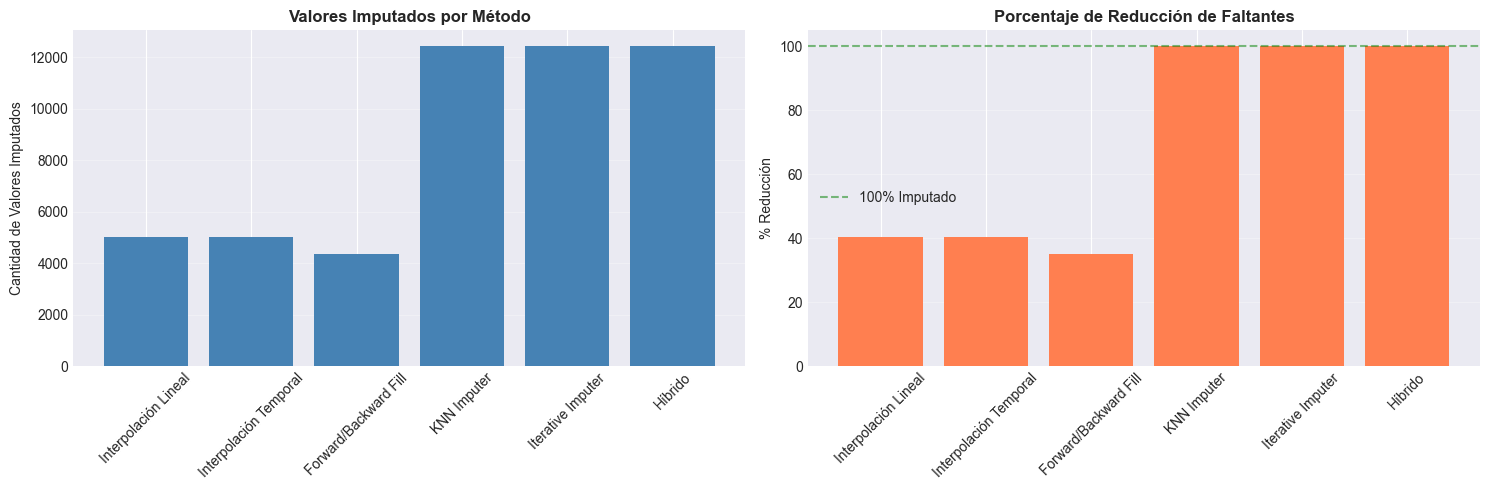

In [18]:
# Resumen comparativo
comparison = pd.DataFrame({
    'Método': ['Original', 'Interpolación Lineal', 'Interpolación Temporal', 
               'Forward/Backward Fill', 'KNN Imputer', 'Iterative Imputer', 'Híbrido'],
    'Faltantes': [missing_before, missing_after, missing_after_time, 
                  missing_after_fill, missing_after_knn, missing_after_iter, missing_after_hybrid],
    'Imputados': [0, missing_before - missing_after, missing_before - missing_after_time,
                  missing_before - missing_after_fill, missing_before - missing_after_knn,
                  missing_before - missing_after_iter, missing_before - missing_after_hybrid]
})

comparison['% Reducción'] = (comparison['Imputados'] / missing_before * 100).round(2)

print("\n" + "="*70)
print("COMPARACIÓN DE MÉTODOS DE IMPUTACIÓN")
print("="*70)
print(comparison.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de barras: valores imputados
comparison_plot = comparison[comparison['Método'] != 'Original']
axes[0].bar(comparison_plot['Método'], comparison_plot['Imputados'], color='steelblue')
axes[0].set_title('Valores Imputados por Método', fontsize=12, weight='bold')
axes[0].set_ylabel('Cantidad de Valores Imputados')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de barras: % reducción
axes[1].bar(comparison_plot['Método'], comparison_plot['% Reducción'], color='coral')
axes[1].set_title('Porcentaje de Reducción de Faltantes', fontsize=12, weight='bold')
axes[1].set_ylabel('% Reducción')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100% Imputado')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Validación de Imputación

Verificamos que los valores imputados sean razonables comparando distribuciones.

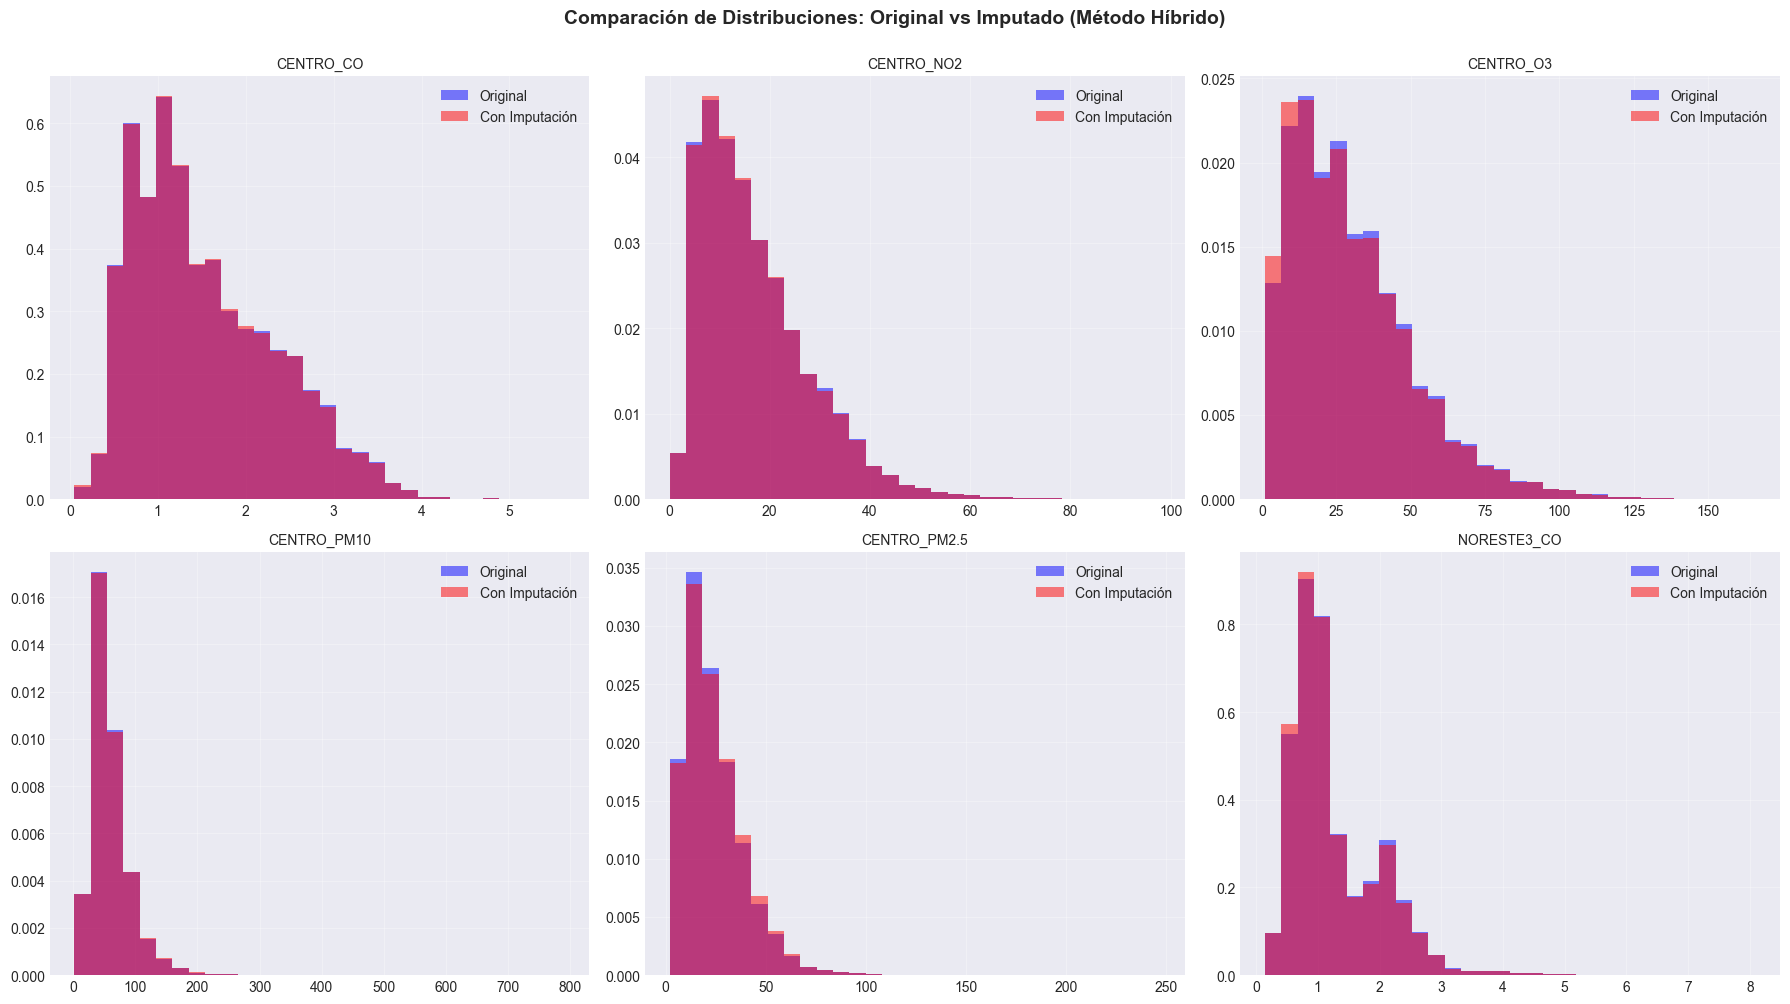

In [19]:
# Comparar distribuciones antes y después (usando método híbrido)
# Seleccionar algunas columnas para visualizar
sample_cols = df_numeric.columns[:min(6, len(df_numeric.columns))]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(sample_cols):
    if idx < len(axes):
        # Valores originales (sin NaN)
        original_values = df_numeric[col].dropna()
        # Valores imputados
        imputed_values = df_hybrid[col]
        
        axes[idx].hist(original_values, bins=30, alpha=0.5, label='Original', color='blue', density=True)
        axes[idx].hist(imputed_values, bins=30, alpha=0.5, label='Con Imputación', color='red', density=True)
        axes[idx].set_title(f'{col}', fontsize=10)
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

plt.suptitle('Comparación de Distribuciones: Original vs Imputado (Método Híbrido)', 
             fontsize=14, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 15. Estadísticas Descriptivas

In [20]:
# Comparar estadísticas descriptivas
print("\n" + "="*70)
print("COMPARACIÓN DE ESTADÍSTICAS: ORIGINAL vs IMPUTADO")
print("="*70)

# Seleccionar primeras columnas para ejemplo
sample_cols_stats = df_numeric.columns[:min(5, len(df_numeric.columns))]

for col in sample_cols_stats:
    print(f"\n{col}:")
    print("-" * 50)
    
    stats_orig = df_numeric[col].describe()
    stats_imp = df_hybrid[col].describe()
    
    comp = pd.DataFrame({
        'Original': stats_orig,
        'Imputado': stats_imp,
        'Diferencia': stats_imp - stats_orig,
        '% Cambio': ((stats_imp - stats_orig) / stats_orig * 100).round(2)
    })
    
    print(comp)


COMPARACIÓN DE ESTADÍSTICAS: ORIGINAL vs IMPUTADO

CENTRO_CO:
--------------------------------------------------
           Original      Imputado  Diferencia  % Cambio
count  21388.000000  21883.000000  495.000000      2.31
mean       1.533786      1.529737   -0.004049     -0.26
std        0.799114      0.796368   -0.002746     -0.34
min        0.050000      0.050000    0.000000      0.00
25%        0.900000      0.900000    0.000000      0.00
50%        1.340000      1.340000    0.000000      0.00
75%        2.090000      2.074945   -0.015055     -0.72
max        5.630000      5.630000    0.000000      0.00

CENTRO_NO2:
--------------------------------------------------
           Original      Imputado  Diferencia  % Cambio
count  21321.000000  21883.000000  562.000000      2.64
mean      17.033331     16.979636   -0.053695     -0.32
std       11.012110     10.963520   -0.048590     -0.44
min        0.000000      0.000000    0.000000       NaN
25%        8.500000      8.500000    0

## 16. Selección del Método Final

**Recomendación**: Usar el **Método Híbrido** por las siguientes razones:

1. **Interpolación lineal** para gaps pequeños preserva la continuidad temporal natural
2. **KNN** para gaps mayores aprovecha información de estaciones/contaminantes correlacionados
3. **Balance** entre preservar patrones temporales y aprovechar relaciones espaciales
4. **100% de imputación** sin eliminar observaciones

In [21]:
# Seleccionar método final
print("Seleccionando MÉTODO HÍBRIDO como método final...")

df_final = df_hybrid.copy()

# Agregar columna de fecha
df_final.insert(0, 'date', date_col)

print(f"\nDimensiones finales: {df_final.shape}")
print(f"Valores faltantes totales: {df_final.isnull().sum().sum()}")
print(f"\nPrimeras filas:")
df_final.head()

Seleccionando MÉTODO HÍBRIDO como método final...

Dimensiones finales: (21883, 31)
Valores faltantes totales: 0

Primeras filas:


est_param,date,CENTRO_CO,CENTRO_NO2,CENTRO_O3,CENTRO_PM10,CENTRO_PM2.5,NORESTE3_CO,NORESTE3_NO2,NORESTE3_O3,NORESTE3_PM10,...,SUROESTE2_CO,SUROESTE2_NO2,SUROESTE2_O3,SUROESTE2_PM10,SUROESTE2_PM2.5,SUR_CO,SUR_NO2,SUR_O3,SUR_PM10,SUR_PM2.5
0,2023-01-01 00:00:00,1.67,30.3,9.0,118.0,94.12,2.117333,30.666667,8.300000,129.333333,...,2.405,28.20,12.5,142.5,34.0,2.6000,58.300,6.000000,118.00,82.666667
1,2023-01-01 01:00:00,1.70,28.9,9.0,97.0,96.79,2.529667,32.266667,7.633333,188.333333,...,2.470,25.50,13.5,169.0,30.0,2.8175,48.550,7.250000,172.25,102.726667
2,2023-01-01 02:00:00,1.51,23.2,11.0,103.0,81.23,2.550333,30.933333,6.566667,355.000000,...,2.655,25.60,12.0,202.5,32.0,3.0850,52.975,7.500000,225.00,75.040000
3,2023-01-01 03:00:00,1.30,20.9,11.0,83.0,49.83,2.421000,30.533333,6.133333,269.333333,...,2.090,25.25,11.0,209.0,79.5,3.4175,44.300,6.250000,214.50,68.936667
4,2023-01-01 04:00:00,1.28,20.7,9.0,65.0,40.19,2.214000,30.666667,5.900000,235.000000,...,1.585,21.55,12.5,112.5,47.0,3.4050,48.650,7.333333,233.00,74.853333


## 17. Convertir de Vuelta a Formato Long (Opcional)

Si los análisis posteriores requieren formato long (estacion, parametro, valor).

In [22]:
# Verificar si necesitamos convertir a formato long
if 'parametro' in df.columns:
    print("Convirtiendo datos imputados de formato wide a long...")
    
    # Separar fecha
    df_final_wide = df_final.copy()
    
    # Melt (unpivot) para volver a formato long
    df_long = df_final_wide.melt(
        id_vars=['date'],
        var_name='est_param',
        value_name='valor'
    )
    
    # Separar estacion y parametro
    df_long[['estacion', 'parametro']] = df_long['est_param'].str.rsplit('_', n=1, expand=True)
    df_long = df_long.drop('est_param', axis=1)
    
    # Reordenar columnas
    df_long = df_long[['date', 'estacion', 'parametro', 'valor']]
    
    # Agregar otras columnas del dataset original si existen
    original_cols = [col for col in df.columns if col not in ['date', 'estacion', 'parametro', 'valor']]
    if original_cols:
        print(f"\nAgregando columnas adicionales del dataset original: {original_cols}")
        # Hacer merge con el dataset original para recuperar esas columnas
        df_original_subset = df[['date', 'estacion', 'parametro'] + original_cols].drop_duplicates()
        df_long = df_long.merge(df_original_subset, on=['date', 'estacion', 'parametro'], how='left')
    
    df_final_to_save = df_long.copy()
    print(f"\nDimensiones formato long: {df_final_to_save.shape}")
    print(f"\nPrimeras filas formato long:")
    print(df_final_to_save.head(10))
    
else:
    print("Los datos ya están en formato wide. Guardando en ese formato.")
    df_final_to_save = df_final.copy()

Convirtiendo datos imputados de formato wide a long...

Dimensiones formato long: (656490, 4)

Primeras filas formato long:
                 date estacion parametro  valor
0 2023-01-01 00:00:00   CENTRO        CO   1.67
1 2023-01-01 01:00:00   CENTRO        CO   1.70
2 2023-01-01 02:00:00   CENTRO        CO   1.51
3 2023-01-01 03:00:00   CENTRO        CO   1.30
4 2023-01-01 04:00:00   CENTRO        CO   1.28
5 2023-01-01 05:00:00   CENTRO        CO   2.12
6 2023-01-01 06:00:00   CENTRO        CO   1.54
7 2023-01-01 07:00:00   CENTRO        CO   1.04
8 2023-01-01 08:00:00   CENTRO        CO   0.98
9 2023-01-01 09:00:00   CENTRO        CO   1.04

Dimensiones formato long: (656490, 4)

Primeras filas formato long:
                 date estacion parametro  valor
0 2023-01-01 00:00:00   CENTRO        CO   1.67
1 2023-01-01 01:00:00   CENTRO        CO   1.70
2 2023-01-01 02:00:00   CENTRO        CO   1.51
3 2023-01-01 03:00:00   CENTRO        CO   1.30
4 2023-01-01 04:00:00   CENTRO        C

## 18. Guardar Datos Imputados

In [23]:
# Guardar datos imputados
print(f"Guardando datos imputados en: {output_file}")

df_final_to_save.to_csv(output_file, index=False)

print(f"\n✓ Datos guardados exitosamente!")
print(f"\nResumen del archivo guardado:")
print(f"  - Ruta: {output_file}")
print(f"  - Dimensiones: {df_final_to_save.shape}")
print(f"  - Valores faltantes: {df_final_to_save.isnull().sum().sum()}")
print(f"  - Tamaño: {output_file.stat().st_size / (1024*1024):.2f} MB")

Guardando datos imputados en: C:\Users\anala\Documents\GitHub\Reto-multivariados-equipo-3\data_processed\datos_sima_imputados.csv

✓ Datos guardados exitosamente!

Resumen del archivo guardado:
  - Ruta: C:\Users\anala\Documents\GitHub\Reto-multivariados-equipo-3\data_processed\datos_sima_imputados.csv
  - Dimensiones: (656490, 4)
  - Valores faltantes: 0
  - Tamaño: 26.03 MB

✓ Datos guardados exitosamente!

Resumen del archivo guardado:
  - Ruta: C:\Users\anala\Documents\GitHub\Reto-multivariados-equipo-3\data_processed\datos_sima_imputados.csv
  - Dimensiones: (656490, 4)
  - Valores faltantes: 0
  - Tamaño: 26.03 MB


## 19. Reporte Final

In [24]:
# Crear reporte final
print("\n" + "="*80)
print("REPORTE FINAL DE IMPUTACIÓN")
print("="*80)

print(f"\n📊 DATASET ORIGINAL:")
print(f"  • Observaciones: {len(df):,}")
print(f"  • Valores totales: {df.size:,}")
print(f"  • Valores faltantes: {df.isnull().sum().sum():,}")
print(f"  • % Faltante: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

print(f"\n📊 DATASET IMPUTADO:")
print(f"  • Observaciones: {len(df_final_to_save):,}")
print(f"  • Valores totales: {df_final_to_save.size:,}")
print(f"  • Valores faltantes: {df_final_to_save.isnull().sum().sum():,}")
print(f"  • % Faltante: {(df_final_to_save.isnull().sum().sum() / df_final_to_save.size * 100):.2f}%")

print(f"\n✅ MÉTODO SELECCIONADO: Híbrido (Interpolación Lineal + KNN)")
print(f"\n💾 ARCHIVO GENERADO: {output_file.name}")

print(f"\n" + "="*80)
print("PRÓXIMOS PASOS:")
print("="*80)
print("\n1. En los notebooks siguientes (02, 03, 04), cambiar:")
print("   Antes: pd.read_csv('datos_sima_limpios_combined.csv')")
print("   Después: pd.read_csv('datos_sima_imputados.csv')")
print("\n2. Comparar resultados de análisis con/sin imputación")
print("\n3. Documentar diferencias en interpretación de resultados")
print("\n4. Validar que los resultados con imputación sean consistentes")
print("\n" + "="*80)


REPORTE FINAL DE IMPUTACIÓN

📊 DATASET ORIGINAL:
  • Observaciones: 1,804,203
  • Valores totales: 7,216,812
  • Valores faltantes: 0
  • % Faltante: 0.00%

📊 DATASET IMPUTADO:
  • Observaciones: 656,490
  • Valores totales: 2,625,960
  • Valores faltantes: 0
  • % Faltante: 0.00%

✅ MÉTODO SELECCIONADO: Híbrido (Interpolación Lineal + KNN)

💾 ARCHIVO GENERADO: datos_sima_imputados.csv

PRÓXIMOS PASOS:

1. En los notebooks siguientes (02, 03, 04), cambiar:
   Antes: pd.read_csv('datos_sima_limpios_combined.csv')
   Después: pd.read_csv('datos_sima_imputados.csv')

2. Comparar resultados de análisis con/sin imputación

3. Documentar diferencias en interpretación de resultados

4. Validar que los resultados con imputación sean consistentes

  • % Faltante: 0.00%

📊 DATASET IMPUTADO:
  • Observaciones: 656,490
  • Valores totales: 2,625,960
  • Valores faltantes: 0
  • % Faltante: 0.00%

✅ MÉTODO SELECCIONADO: Híbrido (Interpolación Lineal + KNN)

💾 ARCHIVO GENERADO: datos_sima_imputados